In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ── Config ─────────────────────────────────────────────────────────────────
DATA_PATH = "data/Dataset/Country-Wise Data/Ireland_dataset.csv"
FEATURES = [
    "Ammonia (mg/l)",
    "Biochemical Oxygen Demand (mg/l)",
    "Dissolved Oxygen (mg/l)",
    "Orthophosphate (mg/l)",
    "pH (ph units)",
    "Temperature (cel)",
    "Nitrogen (mg/l)",
    "Nitrate (mg/l)",
]
TARGET = "CCME_WQI"
RANDOM_SEED = 42
TEST_SIZE = 0.1
VAL_SIZE  = 0.1

In [31]:
# ── 1. Load data ────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df[TARGET].value_counts()}\n")

X = df[FEATURES].values
y_raw = df[TARGET].values

Dataset shape: (235019, 14)

Class distribution:
CCME_WQI
Excellent    197972
Good          33073
Fair           1629
Poor           1423
Marginal        922
Name: count, dtype: int64



In [32]:
# ── 2. Encode target ────────────────────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(y_raw)          # Excellent=0, Fair=1, Good=2, Marginal=3, Poor=4
num_classes = len(le.classes_)
print(f"Classes: {le.classes_}")

Classes: ['Excellent' 'Fair' 'Good' 'Marginal' 'Poor']


In [33]:
# ── 3. Train / test split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=y_train
)
print(f"Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")

Train: 190365  Val: 21152  Test: 23502


In [34]:
# ── 4. Feature scaling ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [35]:
# ── 5. Class weights (handles imbalance) ────────────────────────────────────
class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_arr))
print(f"\nClass weights: { {le.classes_[k]: round(v, 2) for k, v in class_weights.items()} }\n")


Class weights: {'Excellent': np.float64(0.24), 'Fair': np.float64(28.87), 'Good': np.float64(1.42), 'Marginal': np.float64(50.97), 'Poor': np.float64(33.02)}



In [36]:
# ── 6. Build model ──────────────────────────────────────────────────────────
tf.random.set_seed(RANDOM_SEED)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(FEATURES),)),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,421 (48.52 KB)

 Trainable params: 12,037 (47.02 KB)

 Non-trainable params: 384 (1.50 KB)

In [37]:
# ── 7. Callbacks ────────────────────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
]

In [38]:
# ── 8. Train ────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5581 - loss: 1.1173 - val_accuracy: 0.7529 - val_loss: 0.6505 - learning_rate: 0.0010
Epoch 2/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6674 - loss: 0.7034 - val_accuracy: 0.8275 - val_loss: 0.4700 - learning_rate: 0.0010
Epoch 3/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7364 - loss: 0.5682 - val_accuracy: 0.8875 - val_loss: 0.3348 - learning_rate: 0.0010
Epoch 4/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8058 - loss: 0.4708 - val_accuracy: 0.8746 - val_loss: 0.3607 - learning_rate: 0.0010
Epoch 5/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8443 - loss: 0.4139 - val_accuracy: 0.9548 - val_loss: 0.1446 - learning_rate: 0.0010
Epoch 6/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8722 - loss: 0.3710 - val_accuracy: 0.9606 - val_loss: 0.1154 - learning_rate: 0.0010
Epoch 7/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8935 - loss: 0.

In [39]:
# ── 9. Evaluate ─────────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("F1-Score per class:")
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
for cls in le.classes_:
    print(f"{cls}: {report[cls]['f1-score']:.4f}")


Test accuracy: 0.9830  |  Test loss: 0.0454
735/735 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step

Classification Report:
              precision    recall  f1-score   support

   Excellent       0.99      1.00      0.99     19797
        Fair       0.56      0.98      0.71       163
        Good       0.97      0.91      0.94      3308
    Marginal       0.89      0.97      0.93        92
        Poor       1.00      0.94      0.97       142

    accuracy                           0.98     23502
   macro avg       0.88      0.96      0.91     23502
weighted avg       0.99      0.98      0.98     23502

Confusion Matrix:
[[19706     0    91     0     0]
 [    0   159     2     2     0]
 [  172   121  3015     0     0]
 [    0     3     0    89     0]
 [    0     0     0     9   133]]
F1-Score per class:
Excellent: 0.9934
Fair: 0.7130
Good: 0.9398
Marginal: 0.9271
Poor: 0.9673


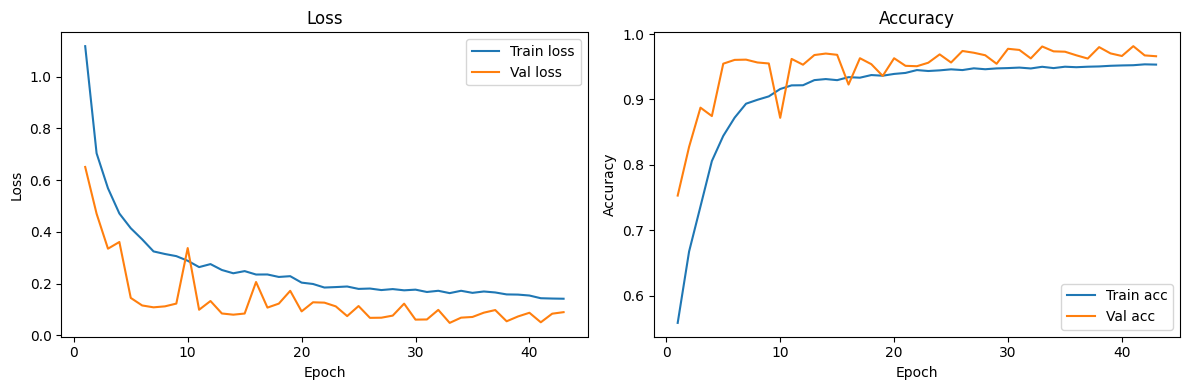

Plot saved to training_curves.png


In [40]:
# ── 10. Training curves ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_ran = range(1, len(history.history["loss"]) + 1)

ax1.plot(epochs_ran, history.history["loss"], label="Train loss")
ax1.plot(epochs_ran, history.history["val_loss"], label="Val loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs_ran, history.history["accuracy"], label="Train acc")
ax2.plot(epochs_ran, history.history["val_accuracy"], label="Val acc")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Plot saved to training_curves.png")


In [42]:
import joblib

# ── 11. Save model + preprocessors ──────────────────────────────────────────
model.save("wqi_model.keras")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(le,     "label_encoder.joblib")
print("Saved: wqi_model.keras | scaler.joblib | label_encoder.joblib")

Saved: wqi_model.keras | scaler.joblib | label_encoder.joblib
